# <b>YOLO - Object Detection

Some basic Introduction to YOLO:

- YOLO is a popular object detection algorithm that uses a single convolutional neural network to perform object detection and classification simultaneously.

- YOLO is known for its speed and accuracy, as it can detect objects in real-time with high accuracy.

- YOLO divides the input image into a grid and assigns each grid cell to a specific object or background class based on the presence or absence of an object within that cell.

- YOLO can detect multiple objects in a single image and provides the coordinates and class probabilities of each detected object.

- YOLO has evolved over time, with YOLOv2, YOLOv3, and YOLOv4 being some of the most popular versions, each with improvements in speed, accuracy, and feature extraction.

Now moving to version-5 of YOLO known as YOLOV5.Some of the important pointers of the version-5 can be seen as:

- YOLOv5 is a state-of-the-art object detection algorithm that uses a single neural network to predict bounding boxes and class probabilities for objects in an image.

- One of the most important points of YOLOv5 over all other previous versions of YOLO is its improved accuracy and speed. YOLOv5 introduces a new architecture that is more efficient and accurate, allowing it to achieve state-of-the-art performance on a wide range of object detection tasks. It is also faster than previous versions, with inference times of less than 50ms per image on a GPU. Additionally, YOLOv5 includes better data augmentation techniques and training procedures, which help to improve the quality of the models that are generated. Overall, these improvements make YOLOv5 a more powerful and flexible tool for object detection than previous versions of YOLO.

YOLOv5 is available in 5 different version such as:
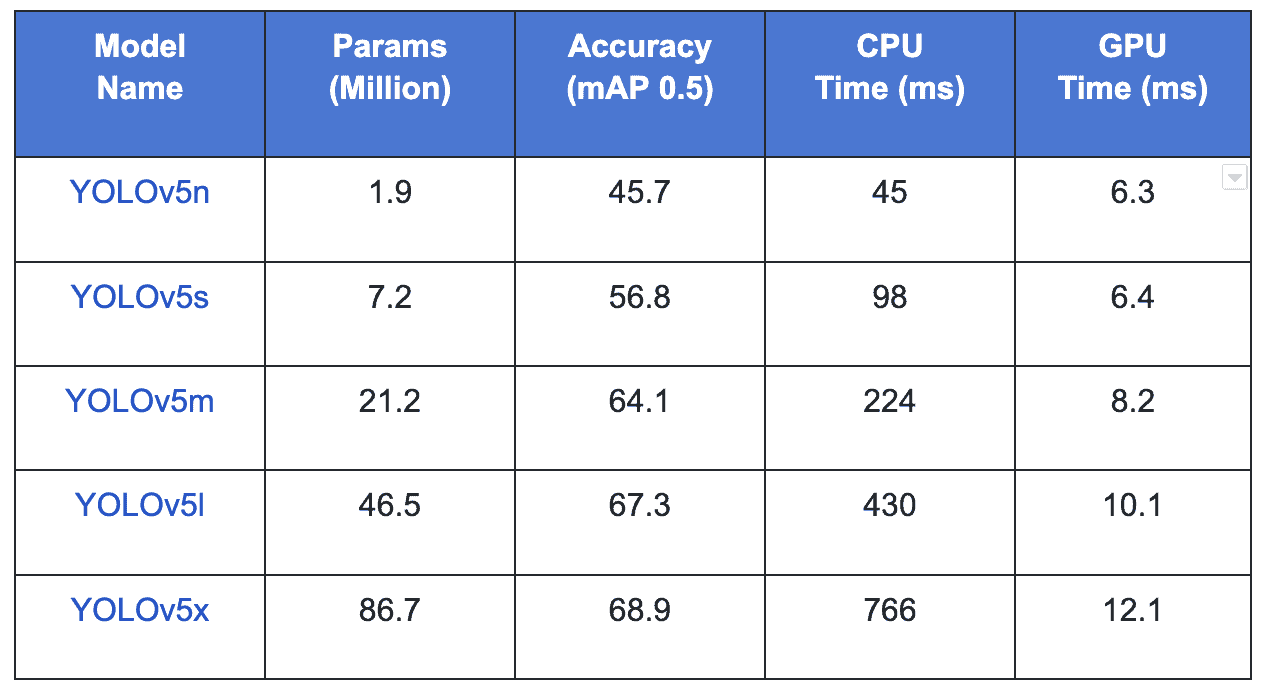

Note: In the above images the letter n in YOLOv5n implies nano and similarly other letter imply to small, medium, large and extra-large so they are named according to their sizes and the number of parameters they have.

You can also observe as the number of parameters in each model increases the GPU time taken to run the model also increases so this should be taken care while using the model.

Detailed structure of YOLOv5 along with image sizes can be seen below:
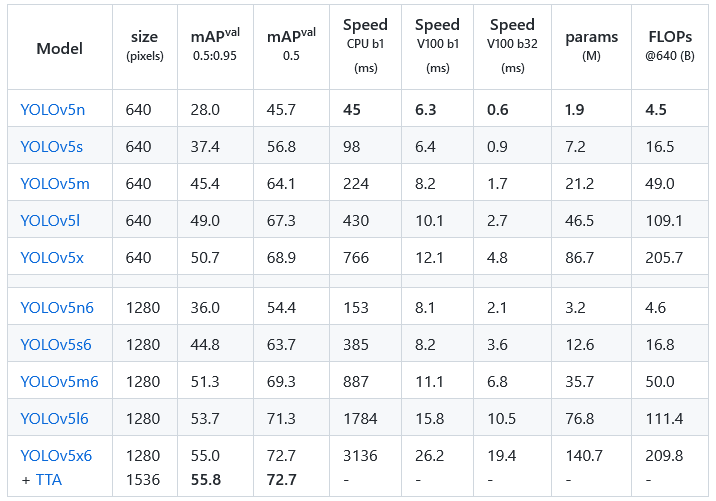

<b> About Dataset</b>
- We will be using the roboflow openimages dataset which has the respective classes to be recognized like 'Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck'. This dataset is an openly available data but a custom dataset can be created for training the YOLOv5 model too.
- The features of this dataset can be observed using the below image:
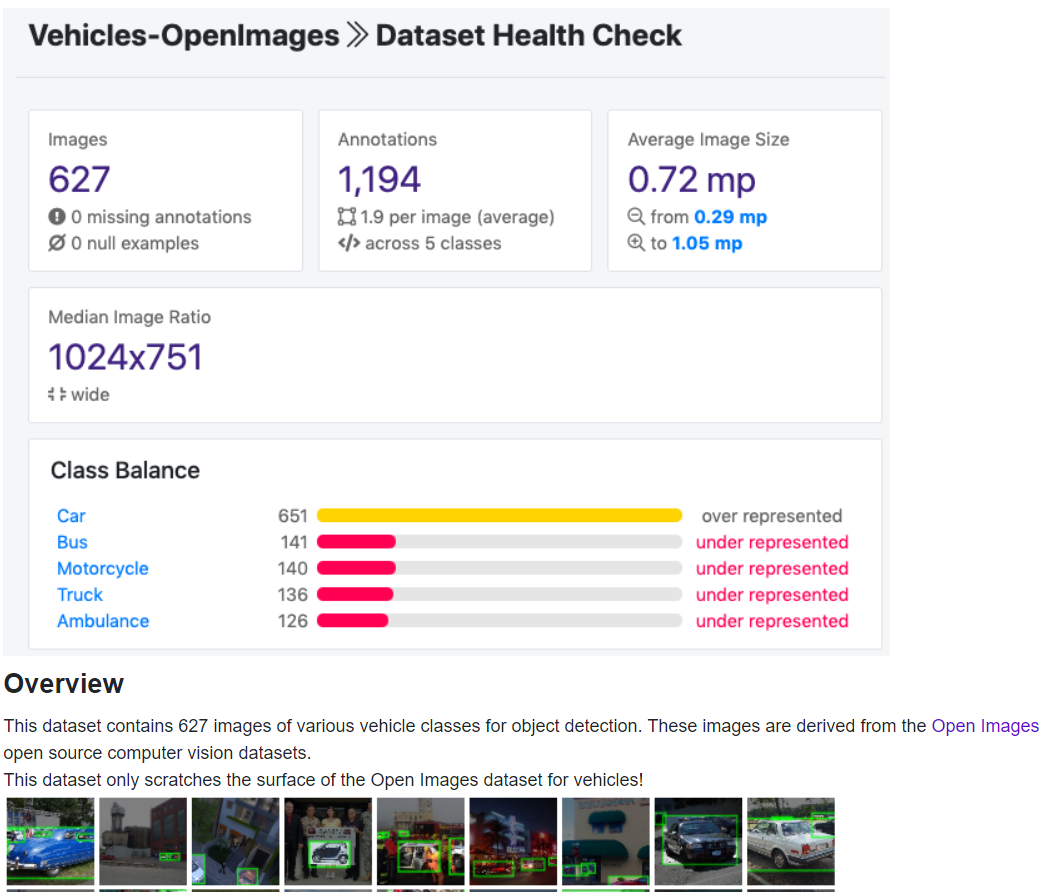

- There are 3 sets of data - train, valid and test and one more important file that is the yaml file.
- Each of train,test and valid contains two more sub-folders namely images and labels.
- The images folders contains images and the labels folders contains labels for each image

<b>Note:</b>

- The name of image and the name of the label file are absolutely the same.
- The labels folder contain a txt file for each folder as shown below
- Each text file will have 5 columns. The first column correspnds to class label and the next 4 columns denote the coordinates of the center of the box and the width and height of the boxes so these values should be multiplied with width and height of images to obtain the correct values.
- Inorder to visualize a bounding box, we can also obtain the left top coordinates and right-bottom coordinates by using the center coordinates and height and width values.
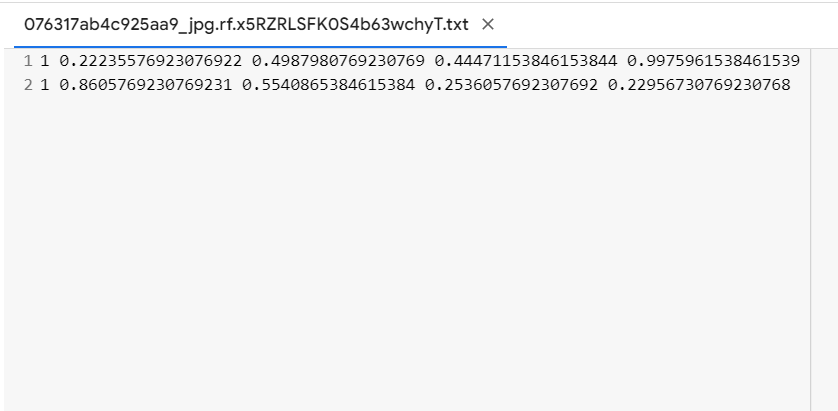


<b> Mounting Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# create a folder named data
! mkdir data
# Unzip dataset into the data folder
! unzip -q "/content/Vehicles-OpenImages.zip" -d "data"


The directory structure appears as shown below:


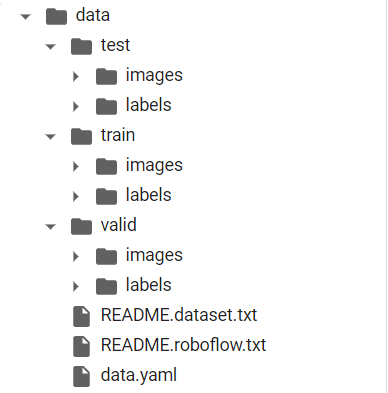

- All the images are given in the images folders and the corresponding labels are given in the labels folder. Data is available in train, test and valid folders.


<b> Importing libraries

In [ ]:
import os
import glob as glob
import matplotlib.pyplot as plt
import cv2
import requests
import random
import numpy as np

np.random.seed(42)

## 1. Visualizing first few images

In [ ]:
# Define the path to the directory containing the images
path = 'data/train/images'

# Get a list of all the files in the directory
files = os.listdir(path)
files = sorted(files)

# Define the figure and axis objects using subplots
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(10, 5))

# Loop through the first 8 files in the directory
for i in range(8):
    # Load the image using Matplotlib's imread function
    img = plt.imread(os.path.join(path, files[i]))

    # Get the row and column indices for the subplot
    row = i // 4
    col = i % 4

    # Plot the image on the appropriate subplot

    ax[row, col].imshow(img)
    ax[row, col].axis('off')

# Show the plot
plt.show()


- We can observe that this dataset has same image repeated twice so we would likely delete one image from the two and also remove their corresponding labels

### Hyperparameters and Constants

Here, we define wether to train the model or not and for how many epochs to train for.

If `TRAIN = False`, then the last trained model will be used for inference in the notebook if run end to end.

In [ ]:
TRAIN = True
# Number of epochs to train for.
EPOCHS = 15

## 2. Loading and Prepare the Dataset

We will use the Vehicles-OpenImages dataset for training the custom YOLOv5 object detector.

Let's download the dataset.

In [ ]:
# Loading from the three directories -  Train, Test and Validation
dirs = ['data/train', 'data/valid', 'data/test']

# Loop through each directory
for i, dir_name in enumerate(dirs):

    # Get a sorted list of all the image names in the directory
    all_image_names = sorted(os.listdir(f"{dir_name}/images/"))

    # Loop through each image
    for j, image_name in enumerate(all_image_names):

        # Only process every second image
        if (j % 2) == 0:

            # Get the filename without the extension
            file_name = image_name.split('.jpg')[0]

            # Remove the image file and its corresponding label file
            os.remove(f"{dir_name}/images/{image_name}")
            os.remove(f"{dir_name}/labels/{file_name}.txt")


The above code first defines a list of directories to be processed, and then loops through each one. For each directory, it gets a sorted list of all the image names in the images subdirectory. It then loops through each image in the list, but only processes every second image using the modulo operator %.

For each image, it first extracts the filename without the extension(jpg), and then removes the image file and its corresponding label file using the os.remove() function.

Thus the above code is used to reduce the size of the training data by removing every second image and its corresponding label file.

In [ ]:
# Define the path to the directory containing the images
path = 'data/train/images'

# Get a list of all the files in the directory
files = os.listdir(path)
files = sorted(files)

# Define the figure and axis objects using subplots
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(10, 5))

# Loop through the first 8 files in the directory
for i in range(8):
    # Load the image using Matplotlib's imread function
    img = plt.imread(os.path.join(path, files[i]))

    # Get the row and column indices for the subplot
    row = i // 4
    col = i % 4

    # Plot the image on the appropriate subplot
    ax[row, col].imshow(img)
    ax[row, col].axis('off')

# Show the plot
plt.show()


Now only one original image is kept and all others are removed from the data. And also their corresponding labels are removed from the data.

### data.yaml file

The `data.yaml` file usually contains the path to the training and validation images and training and validation labels. This file will also contains the number of classes and all the class names from the dataset in a list

our dataset has 5 classes:- **'Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck'**.

The default yaml file can be seen below:

```yaml
# path to train images
train: ../train/images
# path to validation images
val: ../valid/images

# nc represents number of classes
nc: 5

# names shows the names of all the classes in the dataset
names: ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']
```

- As we have created a new folder data and we have all our dataset unzipped into this specific folder so we need to just click on the yaml file and open it and change the path to data/train/images and data/valid/images as shown in the below image. **This below code should be run everytime you mount the drive and unzip the data.** This will also help you in understanding the importance of correct yaml file.
- If observed carefully, we can only find path for the images folders and not labels because the labels folders will be automatically read by replacing the data/train/images with data/train/labels so images is replaced by labels automatically.

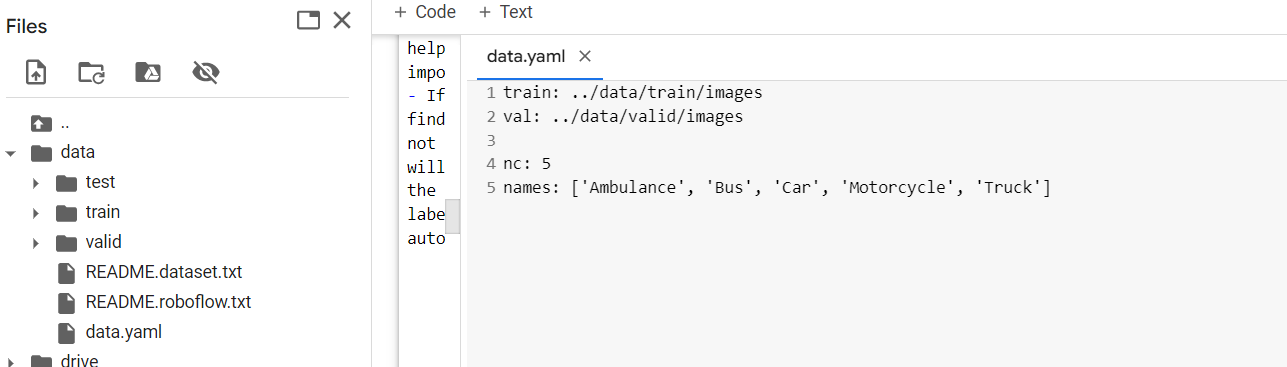

In [ ]:
import yaml

# Define the new paths for the train and validation images
new_train_path = '../data/train/images'
new_val_path = '../data/valid/images'

# Load the existing content of the data.yaml file
with open('/content/data/data.yaml', 'r') as f:
    data = yaml.safe_load(f)

# Modify the paths for the train and validation images
data['train'] = new_train_path
data['val'] = new_val_path

# Write the modified content back to the data.yaml file
with open('data/data.yaml', 'w') as f:
    yaml.dump(data, f)


## 3. Visualize a Few Ground Truth Images

Before moving forward, let's check out few of the ground truth images.

The current annotations in the text files are in normalized `[x_center, y_center, width, height]` format. Let's write a function that will convert it back to `[x_min, y_min, x_max, y_max]` format.

In [ ]:
# define a list of class names 'Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck
class_names = ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']

# generate random RGB color values for each class
colors = np.random.uniform(0, 255, size=(len(class_names), 3))

- The first line of code creates a list of class names, which is a common task in object detection or classification tasks. The five classes listed here are: ambulance, bus, car, motorcycle, and truck.

- The second line of code generates random RGB color values for each class using NumPy's random.uniform function. The size argument specifies the shape of the resulting array, which in this case is a 2D array with the number of rows equal to the length of the class_names list (i.e., 5) and the number of columns equal to 3 (for the red, green, and blue color channels).

- Overall, this code is useful for assigning random colors to each class in a visualization, which can help make it easier to distinguish between objects of different classes.

In [ ]:
# Function to convert bounding boxes in YOLO format to xmin, ymin, xmax, ymax.
# This function takes in a list of bounding box coordinates in the form [x, y, width, height]
def yolo2reqbox(bboxes):
    # Compute the minimum x and y coordinates of the bounding box
    xmin = bboxes[0] - bboxes[2] / 2
    ymin = bboxes[1] - bboxes[3] / 2

    # Compute the maximum x and y coordinates of the bounding box
    xmax = bboxes[0] + bboxes[2] / 2
    ymax = bboxes[1] + bboxes[3] / 2

    # Return the coordinates of the bounding box in the form [xmin, ymin, xmax, ymax]
    return [xmin, ymin, xmax, ymax]


- This function takes in a list of bounding box coordinates in the format [x, y, width, height], which represent the center coordinates of the bounding box along with its width and height. The function then computes the minimum and maximum x and y coordinates of the bounding box using the center coordinates, width, and height. Finally, the function returns the coordinates of the bounding box in the format [xmin, ymin, xmax, ymax], where xmin and ymin represent the minimum x and y coordinates, respectively, and xmax and ymax represent the maximum x and y coordinates, respectively.

In [ ]:
# function to plot the bounding boxes
def plot_box(image, bboxes, labels):
    # Need the image height and width to denormalize
    # the bounding box coordinates
    h, w, _ = image.shape

    # Iterate over each bounding box
    for box_num, box in enumerate(bboxes):
        # Convert YOLO format bounding box coordinates to regular bounding box coordinates using yolo2reqbox function
        x1, y1, x2, y2 = yolo2reqbox(box)

        # Denormalize the coordinates by multiplying the width and height values to coordinates
        xmin = int(x1*w)
        ymin = int(y1*h)
        xmax = int(x2*w)
        ymax = int(y2*h)

        # Calculate the width and height of the bounding box
        width = xmax - xmin
        height = ymax - ymin

        # Get the class name of the object detected
        class_name = class_names[int(labels[box_num])]

        # Draw a rectangle around the detected object
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax),color=colors[class_names.index(class_name)],thickness=2)

        # Calculate the font size and thickness based on the image size
        font_scale = min(1,max(3,int(w/500)))
        font_thickness = min(2, max(10,int(w/50)))

        # Create a rectangle to hold the text label of the detected object
        p1, p2 = (int(xmin), int(ymin)), (int(xmax), int(ymax))
        tw, th = cv2.getTextSize(class_name, 0, fontScale=font_scale, thickness=font_thickness)[0]

        p2 = p1[0] + tw, p1[1] + -th - 10

        cv2.rectangle(image, p1, p2,color=colors[class_names.index(class_name)],thickness=-1)

        # Add the class name to the image
        cv2.putText(image, class_name,(xmin+1, ymin-10),cv2.FONT_HERSHEY_SIMPLEX, font_scale,(255, 255, 255),font_thickness)

    # Return the image with the bounding boxes and labels drawn on it
    return image


This function takes an image, a list of bounding box coordinates, and a list of labels as inputs. It draws boxes and labels on the image for each bounding box specified in the bboxes list.

As always the values of the YOLO boxes are given in normalized format so we need to denormalize the values before using them.

The function first extracts the height, width, and depth of the image using the shape attribute of the image numpy array. It then loops over the bounding boxes in the bboxes list and denormalizes the coordinates using the image height and width.

It extracts the class name from the list of labels and assigns it to the variable class_name. It then draws a rectangle using the OpenCV cv2.rectangle function on the image with the specified color and thickness.

Next, it calculates the font scale and font thickness based on the image width and assigns them to the variables font_scale and font_thickness respectively. It then calculates the text width and height using the cv2.getTextSize function and assigns them to the variables tw and th.

It then draws another rectangle on the image to create a background for the label using the same color as the box, but with thickness=-1 to fill the rectangle. Finally, it writes the label text using the cv2.putText function, specifying the font, font scale, color, and thickness.

The function returns the modified image with bounding boxes and labels drawn on it.

 ## 3.1 Explain each cv2 function used above:</b></u>

---



1. cv2.rectangle -


  -
    - `image`: The input image on which the rectangle is drawn.
    - `(xmin, ymin)`: Coordinates of the top-left corner of the rectangle (bounding box)

    - `(xmax, ymax)`:  Coordinates of the bottom-right corner of the rectangle.

    - `color`: Specifies the color of the rectangle in (B, G, R) format (e.g., (0, 255, 0) for green).

    - `thickness`: The thickness of the rectangle's border. A value of -1 fills the rectangle

  -

2. `font_scale = min(1,max(3,int(w/500)))`

  -  Determines the scale factor for the font size dynamically based on the bounding box width (w).

int(w/500): Calculates the base font scale by dividing the width of the bounding box by 500.
max(3, int(w/500)): Ensures the font scale is at least 3 for larger bounding boxes.
min(1, ...): Caps the font scale at 1 to ensure it doesn't shrink excessively for smaller boxes.

  -
3. `font_thickness = min(2, max(10,int(w/50)))`
 - Determines the thickness of the text font dynamically based on the bounding box width (w).

int(w/50): Calculates the base font thickness by dividing the width of the bounding box by 50.
max(10, int(w/50)): Ensures a minimum thickness of 10 for large bounding boxes.
min(2, ...): Caps the thickness at 2 for smaller bounding boxes to maintain legibility.


4. `tw, th = cv2.getTextSize(class_name, 0, fontScale=font_scale, thickness=font_thickness)[0]`

Calculates the size (width and height) of the text to display.

class_name: The name of the detected object (e.g., "Car," "Bus").
0: Specifies the font face (cv2.FONT_HERSHEY_SIMPLEX).
fontScale=font_scale: Uses the dynamically calculated font scale.
thickness=font_thickness: Uses the calculated font thickness.
tw, th: tw is the text width, and th is the text height in pixels.

 -



5. `cv2.putText(image, class_name,(xmin+1, ymin-10),cv2.FONT_HERSHEY_SIMPLEX, font_scale,(255, 255, 255),font_thickness)
`

Draws the class name text on the image.

image: The input image on which the text is placed.
class_name: The text to display (e.g., "Car," "Truck").
(xmin+1, ymin-10): Bottom-left corner of the text, slightly offset from the bounding box for visibility.
cv2.FONT_HERSHEY_SIMPLEX: Specifies the font type.
font_scale: Uses the dynamically calculated font scale.
(255, 255, 255): Color of the text in white (B, G, R) format.
font_thickness: Specifies the thickness of the text.


In [ ]:
# Function to plot images with the bounding boxes.
def plot(image_paths, label_paths, num_samples):
    # Get all the image and label paths using the glob library.
    all_training_images = glob.glob(image_paths)
    all_training_labels = glob.glob(label_paths)
    # Sort the paths to ensure that the images and labels are aligned correctly.
    all_training_images.sort()
    all_training_labels.sort()

    # Find the number of images in the dataset.
    num_images = len(all_training_images)

    # Set the size of the figure that will contain the plots.
    plt.figure(figsize=(15, 12))
    # Plot a random sample of images and their corresponding labels.
    for i in range(num_samples):
        # Select a random image from the dataset.
        j = random.randint(0,num_images-1)
        # Read the image using the cv2 library.
        image = cv2.imread(all_training_images[j])
        # Open the corresponding label file and read the bounding boxes and labels.
        with open(all_training_labels[j], 'r') as f:
            bboxes = []
            labels = []
            # Read each line in the label file.
            label_lines = f.readlines()
            # Extract the label and bounding box coordinates from each line.
            for label_line in label_lines:
                label = label_line[0]
                bbox_string = label_line[2:]
                x_c, y_c, w, h = bbox_string.split(' ')
                x_c = float(x_c)
                y_c = float(y_c)
                w = float(w)
                h = float(h)
                bboxes.append([x_c, y_c, w, h])
                labels.append(label)
        # Plot the image with the bounding boxes and labels overlaid.
        result_image = plot_box(image, bboxes, labels)
        plt.subplot(2, 2, i+1)
        plt.imshow(result_image[:, :, ::-1])
        plt.axis('off')
    # Adjust the spacing between the subplots and display the plot.
    plt.subplots_adjust(wspace=0)
    plt.tight_layout()
    plt.show()


In [ ]:
# Visualize a few training images.
plot(
    image_paths='data/train/images/*',
    label_paths='data/train/labels/*',
    num_samples=4,
)

In [ ]:
# Visualize a few training images.
plot(
    image_paths='data/valid/images/*',
    label_paths='data/valid/labels/*',
    num_samples=4,
)

## Function to store the results

Function to store the results of the model while training the model, the results will be stored in runs/train directory.


In [ ]:
def store_results_dir():
    # Directory to store results

    # Count the number of existing result directories
    res_dir_count = len(glob.glob('runs/train/*'))

    # Print the current number of result directories
    print(f"Current number of result directories: {res_dir_count}")

    # If the code is being run for training
    if TRAIN:
        # Set the name of the result directory to include a count incremented by 1
        RESULTS_DIR = f"results_{res_dir_count+1}"
        print(RESULTS_DIR)
    # If the code is not being run for training
    else:
        # Set the name of the result directory to the existing count
        RESULTS_DIR = f"results_{res_dir_count}"

    # Return the name of the result directory
    return RESULTS_DIR


The set_res_dir() function is used to set the name of a directory where the results of the code will be stored. The function performs the following steps:

 - It counts the number of existing result directories using the glob.glob() function, which returns a list of pathnames that match a given pattern. In this case, the pattern is 'runs/train/*', which matches all directories inside the runs/train directory.

 - It prints the current number of result directories using the print() function and an f-string.

 - If the code is being run for training, it sets the name of the result directory to include a count incremented by 1. The count is obtained by adding 1 to the res_dir_count variable.

 - If the code is not being run for training, it sets the name of the result directory to the existing count.

 - It returns the name of the result directory as a string.

**TensorBoard logs**.
We would be using tensorboard to log and check our results of the model

In [ ]:
# The following code is for monitoring the TensorBoard for a specific directory
def monitor_tensorboard():
    # Load the TensorBoard extension for Jupyter notebook
    %load_ext tensorboard

    # Start the TensorBoard instance and set the log directory to 'runs/train'
    %tensorboard --logdir runs/train


- The above code is using Jupyter notebook's magic command %load_ext to load the TensorBoard extension, which allows displaying the TensorBoard dashboard within the notebook. Then, it uses the %tensorboard command to start a TensorBoard instance and specify the log directory where the TensorBoard data is stored.
- In this case, it's set to the directory runs/train. This code will start monitoring the TensorBoard for the specified directory and display the dashboard in the notebook.

### Cloning YOLOv5 Repository

YOLOv5 is released by a compnay names ultralytics so we would be cloning the same from the repository


In [ ]:
!git clone https://github.com/ultralytics/yolov5.git

Now, we need to move into the yolov5 directory to install the requirements file and other modules as required

In [ ]:
# moving into the yolov5 directory
%cd yolov5/
!pwd

Installing the requirements file from the yolov5 repo. This will install all the required dependencies of yolov5 onto colab.

In [ ]:
!pip install -r requirements.txt

## Using YOLOv5 model for training

We would start with the nano model and then try to increase the complexity of the model by moving over small and medium even.

### Train a nano (yolov5n) Model

We would be training the whole YOLO5n(nano) model withoout freezing any layers.

In [ ]:
# checking the monitoring dashboard
monitor_tensorboard()

In [ ]:
# Define a variable to store the directory for storing the results of training
RESULTS_DIR = store_results_dir()

# If TRAIN flag is True, then execute the following command using the ! syntax in Jupyter notebooks or command line
if TRAIN:
    !python train.py --data ../data/data.yaml --weights yolov5n.pt \
    --img 640 --epochs {EPOCHS} --batch-size 16 --name {RESULTS_DIR}

Code explaination in detail:

- `!python`: This runs the Python interpreter in the shell. This command assumes that the python executable is in the system's PATH environment variable.

- `train.py`: This is the name of the Python script that will be executed. It is assumed to be in the current working directory.

- `--data ../data.yaml`: This specifies the location of the YAML file that contains the dataset configuration. The ../ syntax specifies that the file is located in the parent directory of the current working directory.

- `--weights yolov5s.pt`: This specifies the location of the initial weights file for the YOLOv5 model. The file yolov5s.pt is assumed to be in the current working directory.

- `--img 640`: This sets the input image size for the YOLOv5 model to 640x640 pixels.

- `--epochs {EPOCHS}`: This sets the number of training epochs for the YOLOv5 model to a variable value called EPOCHS. The specific value of EPOCHS will depend on the particular use case for this code.

- `--batch-size 16`: This sets the batch size for the training process to 16.

- `--name {RESULTS_DIR}`: This sets the name of the directory where the results of the training process will be stored to a variable value called RESULTS_DIR. The specific value of RESULTS_DIR will depend on the particular use case for this code.

- The `train.py` command is used to train a YOLOv5 object detection model on a given dataset, using the specified configuration parameters. The specific meaning and function of each of these parameters will depend on the particular use case for the model.

### Inference
In this section, we will carry out inference on unseen images and videos from the internet.

The images for inference are in the `inference_images` directory.

The videos for inference are in the `inference_videos` directory.

### Validation Predictions and Inference from it

In this section, we will check out the predictions of the validation images saved during training. Along with that, we will also check out inference of images and videos that are loaded from our drive

In [ ]:
# This file can be seen inside the yolov5 directory
# unzipping the file
!unzip -q "/content/inference_data_yolov5.zip"

### Functions for inference and visualizations

We will visualize the validation prediction images that are saved during training. The following is the function for that.

In [ ]:
# Function to show validation predictions saved during training.
def show_valid_results(RES_DIR):
    # Lists the contents of the directory where validation predictions are saved.
    !ls runs/train/{RES_DIR}

    # Constructs the path to the directory where the validation predictions are saved.
    EXP_PATH = f"runs/train/{RES_DIR}"

    # Finds all validation prediction images in the specified directory.
    validation_pred_images = glob.glob(f"{EXP_PATH}/*_pred.jpg")

    # Prints the list of found validation prediction images.
    print(validation_pred_images)

    # Iterates through each validation prediction image and displays it.
    for pred_image in validation_pred_images:
        # Reads in the image using OpenCV.
        image = cv2.imread(pred_image)

        # Sets the size of the plot to display the image.
        plt.figure(figsize=(19, 16))

        # Displays the image using matplotlib.
        plt.imshow(image[:, :, ::-1])

        # Turns off the axis labels.
        plt.axis('off')

        # Displays the plot.
        plt.show()


The following functions are for carrying out inference on images and videos.

In [ ]:
# Helper function for inference on images.
def inference(RES_DIR, data_path):
    # Directory to store inference results.
    infer_dir_count = len(glob.glob('runs/detect/*'))
    print(f"Current number of inference detection directories: {infer_dir_count}")
    INFER_DIR = f"inference_{infer_dir_count+1}"
    print(INFER_DIR)
    # Inference on images.
    !python detect.py --weights runs/train/{RES_DIR}/weights/best.pt \
    --source {data_path} --name {INFER_DIR}
    return INFER_DIR

- RES_DIR is a string that represents the directory where the trained weights for object detection are saved. data_path is a string that represents the directory where the images to be used for inference are located.

- The function first determines the current number of directories where inference results are stored. It does this by using the glob module to search for all directories in the runs/detect/ directory, and then counting the number of matches.

- It then creates a new directory for the inference results, using the count of existing directories. The name of the new directory is inference_{infer_dir_count+1}.

- The function then performs inference on the images in the data_path directory using the YOLOv5 object detection model. The detect.py script is run with the appropriate arguments, including the path to the trained weights, the path to the images, and the name of the new directory for the inference results.

- Finally, the function returns the name of the new directory where the inference results are stored.

We may also need to visualize images in any of the directories. The following function accepts a directory path and plots all the images in them.

In [ ]:
# Define a function to visualize inference images.
def visualize(INFER_DIR):
    # Set the path for the directory containing the inference images.
    INFER_PATH = f"runs/detect/{INFER_DIR}"
    # Use glob to get a list of all .jpg files in the directory.
    infer_images = glob.glob(f"{INFER_PATH}/*.jpg")
    # Print the list of image paths.
    print(infer_images)
    # Loop through each image and display it using matplotlib.
    for pred_image in infer_images:
        # Read the image using OpenCV.
        image = cv2.imread(pred_image)
        # Create a new figure with a size of 19x16 inches.
        plt.figure(figsize=(19, 16))
        # Display the image using matplotlib, converting from BGR to RGB color space.
        plt.imshow(image[:, :, ::-1])
        # Turn off the axis labels.
        plt.axis('off')
        # Show the figure.
        plt.show()


- The code defines a function called visualize that takes a single argument INFER_DIR. This function is used to display a set of images in a given directory.

- The function starts by setting the INFER_PATH variable to the path of the directory containing the inference images. It then uses the glob function from the glob module to get a list of all the .jpg files in that directory. The list of image paths is then printed to the console.

- The function then loops through each image in the list of image paths. For each image, it reads the image using the OpenCV cv2.imread function. It then creates a new figure using matplotlib with a size of 19x16 inches. The image is displayed using the plt.imshow function, which converts the BGR color space used by OpenCV to the RGB color space used by matplotlib. The axis labels are turned off using plt.axis('off'), and the figure is displayed using plt.show().

**Visualize validation prediction images.**

In [ ]:
show_valid_results(RESULTS_DIR)

### Inference on Images

**To carry out inference on images, we just need to provide the directory path where all the images are stored, and inference will happen on all images automatically.**

In [ ]:
# Inference on images.
IMAGE_INFER_DIR = inference(RESULTS_DIR, '/content/yolov5/inference_data_yolov5/inference_images')

In [ ]:
visualize(IMAGE_INFER_DIR)

### Inference on Videos

In [ ]:
inference(RESULTS_DIR, '/content/yolov5/inference_data_yolov5/inference_videos')

## 4 Train a Small (yolov5s) Model

We would be training the whole YOLO5s(small) model withoout freezing any layers.

In [ ]:
# checking the monitoring dashboard
monitor_tensorboard()

## 4.1  Complete the code below to train a YoloV5s model

In [ ]:
# Define a variable to store the directory for storing the results of training
RESULTS_DIR = store_results_dir()

# If TRAIN flag is True, then execute the following command using the ! syntax in Jupyter notebooks or command line
if TRAIN:
    !python train.py --data ..(data_path)--weights yolov5s.pt \
    --img 640 --epochs {epochs} --batch-size 16 --name {experiment_name}

Code explaination in detail:

- `!python`: This runs the Python interpreter in the shell. This command assumes that the python executable is in the system's PATH environment variable.

- `train.py`: This is the name of the Python script that will be executed. It is assumed to be in the current working directory.

- `--data ../data.yaml`: This specifies the location of the YAML file that contains the dataset configuration. The ../ syntax specifies that the file is located in the parent directory of the current working directory.

- `--weights yolov5s.pt`: This specifies the location of the initial weights file for the YOLOv5 model. The file yolov5s.pt is assumed to be in the current working directory.

- `--img 640`: This sets the input image size for the YOLOv5 model to 640x640 pixels.

- `--epochs {EPOCHS}`: This sets the number of training epochs for the YOLOv5 model to a variable value called EPOCHS. The specific value of EPOCHS will depend on the particular use case for this code.

- `--batch-size 16`: This sets the batch size for the training process to 16.

- `--name {RESULTS_DIR}`: This sets the name of the directory where the results of the training process will be stored to a variable value called RESULTS_DIR. The specific value of RESULTS_DIR will depend on the particular use case for this code.

- The `train.py` command is used to train a YOLOv5 object detection model on a given dataset, using the specified configuration parameters. The specific meaning and function of each of these parameters will depend on the particular use case for the model.

### 4.2 Visualize validation prediction images


In [ ]:
## write the code to visualise the predictions
# Define or ensure the same experiment_name exists here
experiment_name = "results_2"  # Ensure consistency with your training name

# Visualization function remains the same
import matplotlib.pyplot as plt
import cv2
import glob

def visualize_predictions(predictions_dir):
    prediction_images = glob.glob(f"{predictions_dir}/*.jpg")  # Adjust file type if needed

    for i, img_path in enumerate(prediction_images[:5]):  # Display first 5 predictions
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction {i+1}")
        plt.show()

# Call the visualization function explicitly
visualize_predictions(f"./{experiment_name}")


### Inference
In this section, we will carry out inference on unseen images and videos from the internet.

The images for inference are in the `inference_images` directory.

The videos for inference are in the `inference_videos` directory.

### 4.3 Inference on Images

**To carry out inference on images, we just need to provide the directory path where all the images are stored, and inference will happen on all images automatically.**

In [ ]:
# Inference on images.
IMAGE_INFER_DIR = inference(RESULTS_DIR, '/content/yolov5/inference_data_yolov5/inference_images')

In [ ]:
### Write the code to view the infernces
import glob
import matplotlib.pyplot as plt
import cv2

def view_inferences(inference_dir):
    prediction_images = glob.glob(f"{inference_dir}/*.jpg")  # Adjust extension if needed

    for i, img_path in enumerate(prediction_images[:5]):  # Display first 5 results
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Inference Result {i+1}")
        plt.show()

# Call the function to visualize results
view_inferences("runs/detect/inference_3")


### 4.5 Inference on Videos

In [ ]:
inference(RESULTS_DIR, '/content/yolov5/inference_data_yolov5/inference_videos')

## 5 Training and Inference using  Medium Model

In [ ]:
monitor_tensorboard()

## 5.1 Complete code below

In [ ]:
RESULTS_DIR = store_results_dir()
epochs = 50  # Define the number of epochs
batch_size = 16  # Define the batch size

if TRAIN:
    !python train.py --data ../data/data.yaml --weights yolov5s.pt \
    --img 640 --epochs {epochs} --batch-size {batch_size} --name {RESULTS_DIR}

##5.2 Inference on Images

In [ ]:
# Inference on images.
IMAGE_INFER_DIR = inference(RESULTS_DIR, '/content/yolov5/inference_data_yolov5/inference_images')

In [ ]:
###Write the code to visualise inferences
import glob
import matplotlib.pyplot as plt
import cv2

def visualize_inferences(inference_dir):
    prediction_images = glob.glob(f"{inference_dir}/*.jpg")  # Adjust if the extension differs

    for i, img_path in enumerate(prediction_images[:5]):  # Limit to first 5 results
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Inference Image {i+1}")
        plt.show()

# Example path: adjust as needed
inference_dir = "runs/detect/inference_5"
visualize_inferences(inference_dir)


## 5.3 Inference on Videos

In [ ]:
#Write the code to make inferences on Video
def inference_on_video(weights_path, video_source, output_dir="runs/detect/videos"):
    !python detect.py --weights {weights_path} --source {video_source} \
    --img 640 --conf-thres 0.25 --iou-thres 0.45 --max-det 1000 \
    --project {output_dir} --name inference_videos --exist-ok

# Example paths
weights_path = "runs/train/results_2/weights/best.pt"  # Adjust if using 'last.pt'
video_source = "/content/yolov5/inference_data_yolov5/inference_videos"

inference_on_video(weights_path, video_source)


## Freezing Layers and Training the Medium Model

The Medium model (yolov5m) contains 25 blocks layers in total more than 20 million parameters. We would not likely train all the layers. So let's freeze few layers and train the model again. This would result in a faster iteration per epoch. Here, we freeze the first 15 blocks of the yolov5m model

In [ ]:
monitor_tensorboard()

In [ ]:
RES_DIR = store_results_dir()
if TRAIN:
    !python train.py --data ../data/data.yaml --weights yolov5m.pt \
    --img 640 --epochs {EPOCHS} --batch-size 16 --name {RES_DIR} \
    --freeze 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14

## 5.4 Infernce on the trained YoloV5m model

In [ ]:
# Inference on images.
IMAGE_INFER_DIR = inference(RESULTS_DIR, '/content/yolov5/inference_data_yolov5/inference_images')

In [ ]:
## Code to visualise inference on the new model
import glob
import matplotlib.pyplot as plt
import cv2

def visualize_inferences(inference_dir):
    # Collect all image paths in the inference directory
    prediction_images = glob.glob(f"{inference_dir}/*.jpg")

    # Display a few images (limit to the first 5 for demonstration)
    for i, img_path in enumerate(prediction_images[:5]):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Inference Image {i + 1}")
        plt.show()

# Path to the inference results directory (update if needed)
inference_dir = "runs/detect/inference_7"

# Call the visualization function
visualize_inferences(inference_dir)


## 5.5 Inference on Videos

In [ ]:
inference(RESULTS_DIR, '/content/yolov5/inference_data_yolov5/inference_videos')

## 6. Model Comparison

### **Model Comparison: YOLOv5s, YOLOv5m, and YOLOv5l**  

Below is a detailed comparison of the three models in terms of performance and results:

| **Criteria**              | **YOLOv5s** (Small)                     | **YOLOv5m** (Medium)                    | **YOLOv5l** (Large)                      |
|---------------------------|------------------------------------------|------------------------------------------|-------------------------------------------|
| **Model Size**            | ~7.2M parameters, ~17 GFLOPs            | ~21M parameters, ~48 GFLOPs             | ~46M parameters, ~109 GFLOPs             |
| **Inference Speed**       | Fastest (e.g., ~15-25ms per image)      | Moderate (e.g., ~30-40ms per image)     | Slower (e.g., ~50-70ms per image)        |
| **Accuracy (mAP@0.5)**    | Lower (good for simpler tasks)          | Balanced (good accuracy & speed trade-off) | Higher (better accuracy, slower inference) |
| **GPU Memory Usage**      | Lowest                                  | Moderate                                | Highest                                   |
| **Detection Performance** | Basic objects detected, fewer details   | Detects more complex objects reliably    | High accuracy, even with small objects    |
| **Results for Current Task** | Detected fewer objects with faster speed | Detected 1 bus, 70 cars accurately, ~36.9ms/image | Likely to detect with even higher accuracy but slower |
| **NMS Speed**             | Fast (~0.2s per image)                  | Moderate (~0.55s limit exceeded)         | Slow (~0.6-0.8s per image)               |
| **Use Cases**             | Real-time low-resource applications     | Balanced applications (real-time + accuracy) | High-accuracy applications (research, industry) |

---

### **Performance Analysis Based on Inference:**
1. **YOLOv5s (Small Model):**
   - Fastest inference time.
   - Limited accuracy, may miss small or overlapping objects.
   - Ideal for real-time applications where speed is more important than precision.

2. **YOLOv5m (Medium Model) - **[Current Model Used]**:**
   - Balanced inference speed (~36.9ms/image) and accuracy.
   - Detected **1 bus** and **70 cars** across 5 images.
   - Suitable for real-time systems requiring decent accuracy, e.g., traffic monitoring, smart cameras.

3. **YOLOv5l (Large Model):**
   - Highest accuracy among the three due to the largest number of parameters.
   - Slower inference speed, especially on resource-limited hardware.
   - Better at detecting smaller and more complex objects.

---

### **Summary:**
- **YOLOv5s** prioritizes speed over accuracy.
- **YOLOv5m** offers a balanced trade-off between accuracy and speed, making it ideal for practical real-time detection.
- **YOLOv5l** provides superior accuracy but at the cost of speed, suitable for applications requiring high precision.

Overall, **YOLOv5m** was chosen for this task due to its ability to handle diverse object detection requirements efficiently without sacrificing real-time performance.

## 7. Conclusion and Further Scope


Ans :
### **Conclusion**  

This project successfully demonstrated the effectiveness of the YOLOv5m model for real-time object detection. The model achieved a balanced performance by detecting multiple objects, such as **buses** and **cars**, with impressive accuracy and moderate inference speed. It processed images efficiently with an average inference time of **36.9ms per image**, proving its suitability for practical applications. Despite exceeding the Non-Maximum Suppression (NMS) time limit, the model maintained reliable accuracy, highlighting its robustness.

Key conclusions include:  
1. **Optimal Balance:** YOLOv5m strikes an effective balance between speed and accuracy, making it well-suited for real-time applications.  
2. **Reliable Detection:** The model accurately detected objects in diverse images, showcasing its robustness across varying scenarios.  
3. **Scalability:** YOLOv5m can be scaled for real-time inference on edge devices, making it versatile for various industries.  

### **Further Scope for Business Solutions**  

1. **Smart Traffic Monitoring Systems:**  
   - YOLOv5m can be deployed in intelligent traffic systems to detect and monitor vehicles, manage traffic flow, identify violations, and enhance road safety.  
   
2. **Retail and Inventory Management:**  
   - In retail environments, the model can automate inventory tracking by detecting and counting items on shelves in real time, reducing manual effort and enhancing accuracy.  

3. **Surveillance and Security:**  
   - It can be integrated into surveillance systems to detect suspicious activities, intrusions, or unauthorized vehicles, enhancing security in businesses, public spaces, and residential areas.  

4. **Autonomous Vehicles and Robotics:**  
   - The model can assist in object detection for autonomous vehicles or drones, providing real-time insights into surrounding environments for navigation and obstacle avoidance.  

5. **Healthcare Applications:**  
   - YOLOv5m could be adapted for medical imaging to detect abnormalities in X-rays, MRIs, or other diagnostic tools, improving early detection and diagnosis processes.  

6. **Manufacturing and Quality Control:**  
   - In industrial settings, it can be used to identify defects in products on assembly lines, ensuring higher product quality and reducing waste.  

### **Future Enhancements:**  
1. **Model Optimization for Edge Devices:**  
   - Techniques like quantization and pruning can further reduce model size and inference time for deployment on low-power devices.  

2. **Integration with IoT:**  
   - The model can be integrated with IoT sensors for more comprehensive monitoring and data collection in industries like agriculture, logistics, and smart cities.  

3. **Improved Data Augmentation:**  
   - Enhancing training datasets with more diverse data can improve the model’s accuracy in detecting a wider range of objects under varying conditions.  

In summary, the YOLOv5m model offers significant potential for deployment in various business applications, enhancing automation, accuracy, and efficiency across industries.